# Angie Crews Notebook
## P5: Text Exploration — Group Comparison

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Angie Crews](https://github.com/Angie-Crews)
- Repository: [nlp-03-text-exploration](https://github.com/Angie-Crews/nlp-03-text-exploration)
- Date: 2026-03-27

Purpose

Build on Phase 4 by merging the four categories into two high-level groups —
**Animals** (dog + cat) and **Vehicles** (car + truck) — and comparing
vocabulary patterns between them.

Research Question

**Do animals and vehicles use distinct vocabulary after stopword removal?**

Analytical Questions

- Which tokens are unique to the Animals group versus the Vehicles group?
- How do bigram patterns differ between the two groups?
- Does grouping reveal structure that individual category analysis obscures?

Notes

- This notebook reuses the P4 corpus, preprocessing, and stopwords without change.
- Phase 5 modification: assign group labels, then compare token and bigram patterns by group.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**,
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

## Section 0. How to Use This Notebook

This notebook builds directly on Phase 4. It reuses the same corpus, stopword list,
and tokenization pipeline, then adds a group comparison layer.

Before running:
- Select the project `.venv` kernel
- Run the cells from top to bottom
- Review the saved charts in `docs/images` after execution

Phase 5 focus:
- Assign each document a group label: `animals` (dog + cat) or `vehicles` (car + truck)
- Compare top tokens and bigrams between the two groups
- Identify tokens that are **unique** to each group
- Display a side-by-side group comparison chart and save it to disk

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

In [1]:
# Section 1 Python cell

import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header, log_path
import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


### Configure Logger and Paths

In [2]:
# Section 1 Python cell (logger configuration and path setup)

LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"
PLOTS_PATH: Path = ROOT_PATH / "docs" / "images"
BIGRAM_PLOT_FILE_PATH: Path = PLOTS_PATH / "nlp_corpus_explore_crews_p5_top_bigrams.png"
PLOT_FILE_PATH: Path = PLOTS_PATH / "nlp_corpus_explore_crews_p5_top_tokens.png"

log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION — P5 GROUP COMPARISON")

log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)
log_path(LOG, "PLOTS_PATH", PLOTS_PATH)
log_path(LOG, "BIGRAM_PLOT_FILE_PATH", BIGRAM_PLOT_FILE_PATH)

LOG.info("Logger configured.")

2026-03-27 18:59:12 | INFO | CI | === RUN START ===
2026-03-27 18:59:12 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION — P5 GROUP COMPARISON
2026-03-27 18:59:12 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-27 18:59:12 | INFO | CI | python=3.14.3
2026-03-27 18:59:12 | INFO | CI | os=Windows 11
2026-03-27 18:59:12 | INFO | CI | shell=powershell
2026-03-27 18:59:12 | INFO | CI | cwd=notebooks
2026-03-27 18:59:12 | INFO | CI | github_actions=False
2026-03-27 18:59:12 | INFO | CI | ROOT_PATH = .
2026-03-27 18:59:12 | INFO | CI | NOTEBOOKS_PATH = notebooks
2026-03-27 18:59:12 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-27 18:59:12 | INFO | CI | PLOTS_PATH = docs\images
2026-03-27 18:59:12 | INFO | CI | BIGRAM_PLOT_FILE_PATH = docs\images\nlp_corpus_explore_crews_p5_top_bigrams.png
2026-03-27 18:59:12 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

In [3]:
# Section 2 Python cell

# A corpus is a collection of text documents.
# Each document is associated with a category label.
# Use a list of dictionaries to represent the corpus in memory.
# A dictionary uses labeled key:value pairs.
# Key:value pairs let us store the category and the text together.

corpus = [
    {"category": "dog", "text": "A dog barks loudly."},
    {"category": "dog", "text": "The puppy runs in the yard."},
    {"category": "dog", "text": "A canine wears a leash."},
    {"category": "dog", "text": "The kennel holds the dog."},
    {"category": "dog", "text": "The dog ran across the yard."},
    {"category": "dog", "text": "The puppy ran across the yard."},
    {"category": "cat", "text": "A cat sleeps quietly."},
    {"category": "cat", "text": "The kitten plays with yarn."},
    {"category": "cat", "text": "A feline purrs softly."},
    {"category": "cat", "text": "The cat has whiskers."},
    {"category": "cat", "text": "The cat slept near the window."},
    {"category": "cat", "text": "The kitten slept near the window."},
    {"category": "car", "text": "A car drives on the road."},
    {"category": "car", "text": "The sedan parks in the garage."},
    {"category": "car", "text": "A vehicle has four wheels."},
    {"category": "car", "text": "The car moves down the highway."},
    {"category": "car", "text": "The car stopped near the garage."},
    {"category": "car", "text": "The sedan stopped near the garage."},
    {"category": "truck", "text": "A truck carries cargo."},
    {"category": "truck", "text": "The pickup pulls a trailer."},
    {"category": "truck", "text": "The engine powers the truck."},
    {"category": "truck", "text": "The truck hauls heavy loads."},
]

print(f"Corpus contains {len(corpus)} documents.")

Corpus contains 22 documents.


## Section 3. Tokenize and Clean Text

In [4]:
# Section 3 Python cell

# Tokenization splits text into word-like units.

STOPWORDS: set[str] = {
    "the",
    "a",
    "an",
    "in",
    "on",
    "with",
    "has",
    "down",
    "near",
}


def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    return [t.strip(".,:;!?()[]\"'") for t in tokens if len(t) > 2]


records_list: list[dict[str, str]] = []
for doc in corpus:
    tokens = tokenize(doc["text"])
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

token_df: pl.DataFrame = pl.DataFrame(records_list)
filtered_token_df: pl.DataFrame = token_df.filter(~pl.col("token").is_in(STOPWORDS))

print("Tokenization complete.")
print(token_df.head(10))
print(
    f"Removed {token_df.height - filtered_token_df.height} stopword tokens before analysis."
)
print(filtered_token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌──────────┬────────┐
│ category ┆ token  │
│ ---      ┆ ---    │
│ str      ┆ str    │
╞══════════╪════════╡
│ dog      ┆ dog    │
│ dog      ┆ barks  │
│ dog      ┆ loudly │
│ dog      ┆ the    │
│ dog      ┆ puppy  │
│ dog      ┆ runs   │
│ dog      ┆ the    │
│ dog      ┆ yard   │
│ dog      ┆ canine │
│ dog      ┆ wears  │
└──────────┴────────┘
Removed 35 stopword tokens before analysis.
shape: (10, 2)
┌──────────┬────────┐
│ category ┆ token  │
│ ---      ┆ ---    │
│ str      ┆ str    │
╞══════════╪════════╡
│ dog      ┆ dog    │
│ dog      ┆ barks  │
│ dog      ┆ loudly │
│ dog      ┆ puppy  │
│ dog      ┆ runs   │
│ dog      ┆ yard   │
│ dog      ┆ canine │
│ dog      ┆ wears  │
│ dog      ┆ leash  │
│ dog      ┆ kennel │
└──────────┴────────┘


## Section 4. Assign Group Labels (Animals vs Vehicles)

Map each document's category to a two-group label.
This collapses the four categories into two high-level groups for comparison.

In [5]:
# Section 4 Python cell

# Map fine-grained categories to two groups.
# Animals: dog + cat     Vehicles: car + truck

GROUP_MAP: dict[str, str] = {
    "dog": "animals",
    "cat": "animals",
    "car": "vehicles",
    "truck": "vehicles",
}

# Add a group column to the filtered token DataFrame.
group_token_df: pl.DataFrame = filtered_token_df.with_columns(
    pl.col("category").replace(GROUP_MAP).alias("group")
)

print("Group label sample:")
print(group_token_df.head(10))
print(f"\nGroups present: {sorted(group_token_df['group'].unique().to_list())}")

Group label sample:
shape: (10, 3)
┌──────────┬────────┬─────────┐
│ category ┆ token  ┆ group   │
│ ---      ┆ ---    ┆ ---     │
│ str      ┆ str    ┆ str     │
╞══════════╪════════╪═════════╡
│ dog      ┆ dog    ┆ animals │
│ dog      ┆ barks  ┆ animals │
│ dog      ┆ loudly ┆ animals │
│ dog      ┆ puppy  ┆ animals │
│ dog      ┆ runs   ┆ animals │
│ dog      ┆ yard   ┆ animals │
│ dog      ┆ canine ┆ animals │
│ dog      ┆ wears  ┆ animals │
│ dog      ┆ leash  ┆ animals │
│ dog      ┆ kennel ┆ animals │
└──────────┴────────┴─────────┘

Groups present: ['animals', 'vehicles']


## Section 5. Compute Token Frequencies by Group

In [6]:
# Section 5 Python cell

# Compare token usage across the two groups.

group_freq_df: pl.DataFrame = (
    group_token_df.group_by(["group", "token"])
    .len()
    .sort(["group", "len"], descending=True)
)

print("Top tokens by group:")
print(group_freq_df.head(14))

Top tokens by group:
shape: (14, 3)
┌──────────┬─────────┬─────┐
│ group    ┆ token   ┆ len │
│ ---      ┆ ---     ┆ --- │
│ str      ┆ str     ┆ u32 │
╞══════════╪═════════╪═════╡
│ vehicles ┆ car     ┆ 3   │
│ vehicles ┆ garage  ┆ 3   │
│ vehicles ┆ truck   ┆ 3   │
│ vehicles ┆ stopped ┆ 2   │
│ vehicles ┆ sedan   ┆ 2   │
│ …        ┆ …       ┆ …   │
│ vehicles ┆ loads   ┆ 1   │
│ vehicles ┆ heavy   ┆ 1   │
│ vehicles ┆ parks   ┆ 1   │
│ vehicles ┆ vehicle ┆ 1   │
│ vehicles ┆ cargo   ┆ 1   │
└──────────┴─────────┴─────┘


## Section 6. Identify Top Tokens per Group

In [7]:
# Section 6 Python cell

# Show top tokens per group.

top_per_group_dict: dict[str, list[str]] = {}

for group in sorted(group_token_df["group"].unique().to_list()):
    subset_df = group_freq_df.filter(pl.col("group") == group).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_group_dict[group] = top_tokens_list
    print(f"{group.upper()} top tokens: {top_tokens_list}")

ANIMALS top tokens: ['yard', 'dog', 'cat', 'ran', 'slept']
VEHICLES top tokens: ['car', 'garage', 'truck', 'stopped', 'sedan']


## Section 7. Identify Tokens Unique to Each Group

A token is **unique** to a group if it never appears in the other group.
These are the clearest vocabulary signals separating Animals from Vehicles.

In [8]:
# Section 7 Python cell

# Find tokens that appear in one group but not the other.

animals_tokens: set[str] = set(
    group_token_df.filter(pl.col("group") == "animals")["token"].to_list()
)
vehicles_tokens: set[str] = set(
    group_token_df.filter(pl.col("group") == "vehicles")["token"].to_list()
)

unique_to_animals: set[str] = animals_tokens - vehicles_tokens
unique_to_vehicles: set[str] = vehicles_tokens - animals_tokens
shared_tokens: set[str] = animals_tokens & vehicles_tokens

print(
    f"Tokens unique to ANIMALS  ({len(unique_to_animals)}): {sorted(unique_to_animals)}"
)
print(
    f"Tokens unique to VEHICLES ({len(unique_to_vehicles)}): {sorted(unique_to_vehicles)}"
)
print(f"Shared tokens             ({len(shared_tokens)}): {sorted(shared_tokens)}")

Tokens unique to ANIMALS  (25): ['across', 'barks', 'canine', 'cat', 'dog', 'feline', 'holds', 'kennel', 'kitten', 'leash', 'loudly', 'plays', 'puppy', 'purrs', 'quietly', 'ran', 'runs', 'sleeps', 'slept', 'softly', 'wears', 'whiskers', 'window', 'yard', 'yarn']
Tokens unique to VEHICLES (23): ['car', 'cargo', 'carries', 'drives', 'engine', 'four', 'garage', 'hauls', 'heavy', 'highway', 'loads', 'moves', 'parks', 'pickup', 'powers', 'pulls', 'road', 'sedan', 'stopped', 'trailer', 'truck', 'vehicle', 'wheels']
Shared tokens             (0): []


## Section 8. Create Bigrams by Group and Compute Frequencies

This section computes bigrams for each group and prints the top word pairs,
showing how local structure (word sequences) differs between Animals and Vehicles.

Top bigrams — ANIMALS:
shape: (5, 3)
┌─────────┬──────────────┬─────┐
│ group   ┆ bigram       ┆ len │
│ ---     ┆ ---          ┆ --- │
│ str     ┆ str          ┆ u32 │
╞═════════╪══════════════╪═════╡
│ animals ┆ across yard  ┆ 2   │
│ animals ┆ ran across   ┆ 2   │
│ animals ┆ slept window ┆ 2   │
│ animals ┆ runs yard    ┆ 1   │
│ animals ┆ plays yarn   ┆ 1   │
└─────────┴──────────────┴─────┘

Top bigrams — VEHICLES:
shape: (5, 3)
┌──────────┬────────────────┬─────┐
│ group    ┆ bigram         ┆ len │
│ ---      ┆ ---            ┆ --- │
│ str      ┆ str            ┆ u32 │
╞══════════╪════════════════╪═════╡
│ vehicles ┆ stopped garage ┆ 2   │
│ vehicles ┆ vehicle four   ┆ 1   │
│ vehicles ┆ sedan parks    ┆ 1   │
│ vehicles ┆ truck carries  ┆ 1   │
│ vehicles ┆ engine powers  ┆ 1   │
└──────────┴────────────────┴─────┘


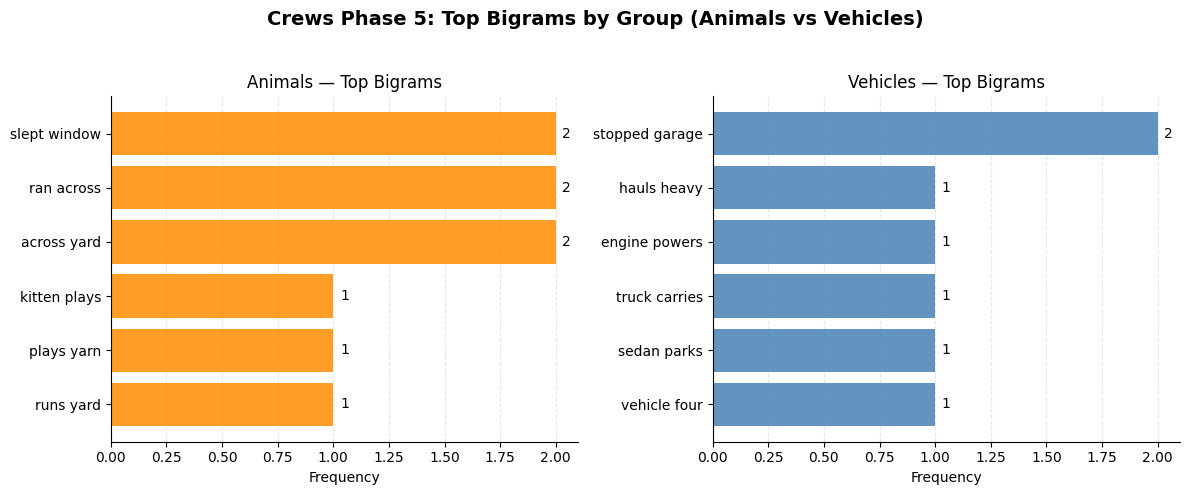

Saved bigram visualization to c:\Repos\nlp-03-text-exploration\docs\images\nlp_corpus_explore_crews_p5_top_bigrams.png


In [9]:
# Section 8 Python cell

# Build bigrams, tagging each with its high-level group label.

bigrams_p5_list: list[dict[str, str]] = []

for doc in corpus:
    group_label = GROUP_MAP[doc["category"]]
    tokens = [token for token in tokenize(doc["text"]) if token not in STOPWORDS]
    for i in range(len(tokens) - 1):
        bigrams_p5_list.append(
            {
                "group": group_label,
                "bigram": f"{tokens[i]} {tokens[i + 1]}",
            }
        )

bigram_p5_df: pl.DataFrame = pl.DataFrame(bigrams_p5_list)

bigram_group_freq_df: pl.DataFrame = (
    bigram_p5_df.group_by(["group", "bigram"])
    .len()
    .sort(["group", "len"], descending=True)
)

print("Top bigrams — ANIMALS:")
print(bigram_group_freq_df.filter(pl.col("group") == "animals").head(5))
print("\nTop bigrams — VEHICLES:")
print(bigram_group_freq_df.filter(pl.col("group") == "vehicles").head(5))

# --- Bigram chart: Animals vs Vehicles side by side ---

group_colors = {"animals": "darkorange", "vehicles": "steelblue"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, group in zip(axes, ["animals", "vehicles"], strict=True):
    top_df = bigram_group_freq_df.filter(pl.col("group") == group).head(6).sort("len")
    ax.barh(
        top_df["bigram"].to_list(),
        top_df["len"].to_list(),
        color=group_colors[group],
        alpha=0.85,
    )
    ax.set_title(f"{group.title()} — Top Bigrams")
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for idx, count in enumerate(top_df["len"].to_list()):
        ax.text(count + 0.03, idx, str(count), va="center")

fig.suptitle(
    "Crews Phase 5: Top Bigrams by Group (Animals vs Vehicles)",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
PLOTS_PATH.mkdir(parents=True, exist_ok=True)
fig.savefig(BIGRAM_PLOT_FILE_PATH, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved bigram visualization to {BIGRAM_PLOT_FILE_PATH}")

## Section 9. Visualize Top Tokens by Group

This chart compares the top tokens in Animals vs Vehicles side by side.
It is displayed inline and saved to `docs/images/nlp_corpus_explore_crews_p5_top_tokens.png`.

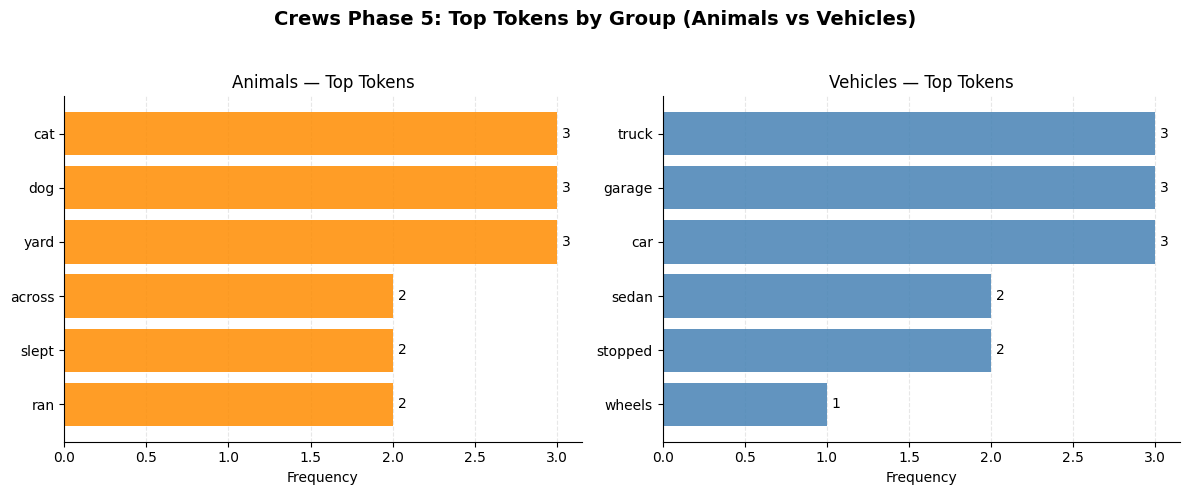

Saved visualization to c:\Repos\nlp-03-text-exploration\docs\images\nlp_corpus_explore_crews_p5_top_tokens.png


In [10]:
# Section 9 Python cell

# Side-by-side bar charts: top tokens for Animals vs Vehicles.

group_colors = {"animals": "darkorange", "vehicles": "steelblue"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, group in zip(axes, ["animals", "vehicles"], strict=True):
    top_group_df = group_freq_df.filter(pl.col("group") == group).head(6).sort("len")
    tokens = top_group_df["token"].to_list()
    counts = top_group_df["len"].to_list()

    ax.barh(tokens, counts, color=group_colors[group], alpha=0.85)
    ax.set_title(f"{group.title()} — Top Tokens")
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for idx, count in enumerate(counts):
        ax.text(count + 0.03, idx, str(count), va="center")

fig.suptitle(
    "Crews Phase 5: Top Tokens by Group (Animals vs Vehicles)",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))

PLOTS_PATH.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_FILE_PATH, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved visualization to {PLOT_FILE_PATH}")

## Section 10. Interpret Results and Identify Patterns

In [13]:
# Section 10 Python cell

print("\nCASE GENERAL OBSERVATIONS:")
print("- Tokens cluster by group (animals vs vehicles).")
print("- Grouping collapses four categories into two, surfacing higher-level patterns.")
print("- Unique-token analysis pinpoints the clearest vocabulary separators.")
print("- Bigram patterns confirm word-sequence differences between groups.")
print("- Structure is visible before any machine learning is applied.")

print("\nCREWS PHASE 5 MODIFICATION:")
print(
    "- I merged the four P4 categories into two groups (animals, vehicles) using GROUP_MAP."
)
print("- I replaced the co-occurrence section with a unique-token comparison.")
print(
    "- I updated both charts (tokens and bigrams) to compare groups side by side instead of four panels."
)
print(
    "- All P4 preprocessing (stopwords, tokenize function, corpus) carried forward unchanged."
)

print("\nCREWS SPECIFIC OBSERVATIONS:")
print(
    "- Animals-unique tokens include creature-specific words (barks, purrs, whiskers, leash, kennel)."
)
print(
    "- Vehicles-unique tokens include motion and load words (highway, cargo, hauls, trailer, wheels)."
)
print(
    "- The shared token 'yard' appears across both groups, suggesting spatial language is not group-specific."
)
print(
    "- Side-by-side charts make group vocabulary differences immediately visible at a glance."
)


CASE GENERAL OBSERVATIONS:
- Tokens cluster by group (animals vs vehicles).
- Grouping collapses four categories into two, surfacing higher-level patterns.
- Unique-token analysis pinpoints the clearest vocabulary separators.
- Bigram patterns confirm word-sequence differences between groups.
- Structure is visible before any machine learning is applied.

CREWS PHASE 5 MODIFICATION:
- I merged the four P4 categories into two groups (animals, vehicles) using GROUP_MAP.
- I replaced the co-occurrence section with a unique-token comparison.
- I updated both charts (tokens and bigrams) to compare groups side by side instead of four panels.
- All P4 preprocessing (stopwords, tokenize function, corpus) carried forward unchanged.

CREWS SPECIFIC OBSERVATIONS:
- Animals-unique tokens include creature-specific words (barks, purrs, whiskers, leash, kennel).
- Vehicles-unique tokens include motion and load words (highway, cargo, hauls, trailer, wheels).
- The shared token 'yard' appears across b

In [12]:
# Final Python cell

LOG.info("========================")
LOG.info("P5 Notebook executed successfully!")
LOG.info("========================")

print("Notebook executed successfully.")

2026-03-27 18:59:13 | INFO | CI | ========================
2026-03-27 18:59:13 | INFO | CI | P5 Notebook executed successfully!
2026-03-27 18:59:13 | INFO | CI | ========================


Notebook executed successfully.
